# Tenancy Services bond data preparation

This notebook is intended to be run to select observations from the Tenancy Services bond dataset that are within the area of interest (Christchurch City) only. It will create a new csv file within ../Data that can be used for future analyses.

Please note: all variables and observations from the Tenancy Services dataset were kept at this stage to retain as much data as possible prior to any analyses in the future. It is expected that filtering to just Christchurch will yield a significant saving with respect to file size.

IMPORTANT: As no observations were removed, each statistical area may have more than one entry per timepoint! (eg, ALL vs house dwelling type

During cleanup, it was noted that the area covered by the AirBnB dataset describes an area based on the combination of wards. Whereas, the Tenancy Services dataset lists bonds lodged per statistical area.

To reconcile this, spatial filtering was used to select the statistical areas in the Tenancy Services dataset that corresponds to the wards used by the AirBnB dataset. Fortunately, the Christchurch City area described within the AirBnB dataset were generally consistent with the statistical areas.

Polygons of statistical areas was obtained from Stats NZ (https://datafinder.stats.govt.nz/layer/98970-statistical-area-2-2019-generalised/) and a GeoJSON of the neighbourhoods covered by the Inside AirBnB dataset is available at https://insideairbnb.com/get-the-data/.

The Tenancy Services bond data (detailed quarterly reports from Jan 2020 to Apr 2026) was obtained from https://www.tenancy.govt.nz/about-tenancy-services/data-and-statistics/rental-bond-data/

In [1]:
# First, starting with imports
import pandas as pd
import geopandas as gpd
import matplotlib as plt

ModuleNotFoundError: No module named 'geopandas'

## Preparing input files

First, the data from Stats NZ and the GeoJSON file from the Inside AirBnB site are loaded below and the coordinate reference systems were aligned to NZGD2000 (EPSG:2193) prior to spatial filtering. Please pay attention to the relative paths for these files below.

In [132]:
# First, loading up the statistical areas
sa_areas = gpd.read_file("../Data/statsnz-statistical-area/statistical-area-2-2019-generalised.shp")

# Coverting CRS to NZGD2000 (EPSG:2193), if not already in EPSG:4326
sa_areas = sa_areas.to_crs(2193)

# Double checking CRS
sa_areas.crs

<Projected CRS: EPSG:2193>
Name: NZGD2000 / New Zealand Transverse Mercator 2000
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: New Zealand - North Island, South Island, Stewart Island - onshore.
- bounds: (166.37, -47.33, 178.63, -34.1)
Coordinate Operation:
- name: New Zealand Transverse Mercator 2000
- method: Transverse Mercator
Datum: New Zealand Geodetic Datum 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [133]:
# Now to load the GeoJSON file
airbnb_all_area = gpd.read_file("../Data/neighbourhoods.geojson")

# Again, converting CRS to EPSG:2193
airbnb_all_area = airbnb_all_area.to_crs(2193)

# Double checking CRS
airbnb_all_area.crs

<Projected CRS: EPSG:2193>
Name: NZGD2000 / New Zealand Transverse Mercator 2000
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: New Zealand - North Island, South Island, Stewart Island - onshore.
- bounds: (166.37, -47.33, 178.63, -34.1)
Coordinate Operation:
- name: New Zealand Transverse Mercator 2000
- method: Transverse Mercator
Datum: New Zealand Geodetic Datum 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## Preparing the AirBnB GeoJSON for spatial filtering

Here, we need to select the polygons/wards that are associated with the neighbourhood_group that belongs to "Christchurch City" and convert this into a single polygon that can be used for the spatial filtering later.

In [134]:
# Subsetting the overall GeoJSON loaded earlier to observations where neighbourhood_group == "Christchurch City"
airbnb_chch_area = airbnb_all_area[airbnb_all_area["neighbourhood_group"] == "Christchurch City"]

# Sanity check of output
airbnb_chch_area.head(5)

,neighbourhood,neighbourhood_group,geometry
24,Harewood Ward,Christchurch City,"MULTIPOLYGON (((1554625.473 5187003.79, 155457..."
25,Innes Ward,Christchurch City,"MULTIPOLYGON (((1570082.785 5183653.974, 15699..."
70,Riccarton Ward,Christchurch City,"MULTIPOLYGON (((1564636.187 5180349.018, 15646..."
71,Heathcote Ward,Christchurch City,"MULTIPOLYGON (((1575157 5178062.308, 1575166.4..."
72,Banks Peninsula Ward,Christchurch City,"MULTIPOLYGON (((1575121.229 5169982.019, 15751..."


<Axes: >

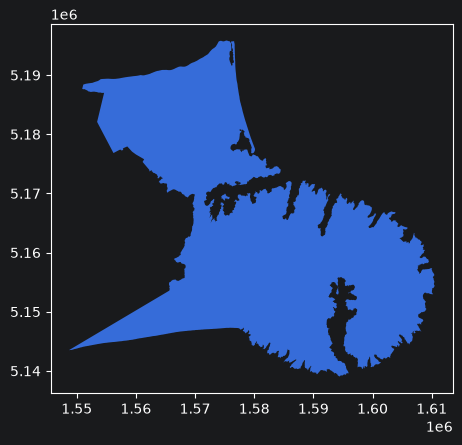

In [135]:
# Dissolving the multiple polys into a single poly for spatial join
airbnb_chch_area = airbnb_chch_area.dissolve(by = "neighbourhood_group")

# Plotting area as a sanity check
airbnb_chch_area.plot()

## Performing spatial filtering to select statistical areas

To select the statistical areas that are contained within the area identified above, only statistical areas that were at least 50% covered by the area above were selected. Otherwise the lack of perfect overlaps between the polygons prevented clean spatial joins, and a centroid-based approach failed due to the harbour.

Please note that in the visualisation, blue indicates the AirBnB area while red indicates the outlines of the statistical areas. Purple indicates overlap.

In [136]:
# Performing spatial join to select SAs that are within the area defined above
boundary = airbnb_chch_area.geometry.iloc[0]

# Calculating coverage of SAs by the boundary area above
overlap_area = sa_areas.intersection(boundary).area
total_area = sa_areas.area
coverage = overlap_area / total_area

# Only selecting SAs with at least 50% coverage
chch_sa = sa_areas[coverage > 0.5]

chch_sa.head(5)

,SA22019_V1,SA22019__1,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry
497,326000,Waimairi Beach,0.581274,0.581274,3931.742757,"POLYGON ((1577029.076 5186085.229, 1576937.234..."
499,316400,McLeans Island,73.943509,73.943509,58217.734085,"POLYGON ((1554625.434 5187003.74, 1554571.174 ..."
500,316500,Paparua,23.341624,23.341624,21771.757495,"POLYGON ((1553906.972 5181197.885, 1553548.43 ..."
501,317100,Brooklands-Spencerville,7.247246,7.247246,25407.578553,"POLYGON ((1574996.703 5194750.551, 1574965.754..."
502,317200,Styx,32.712895,32.712895,33380.997762,"POLYGON ((1572409.78 5193819.678, 1572427.367 ..."


<Axes: >

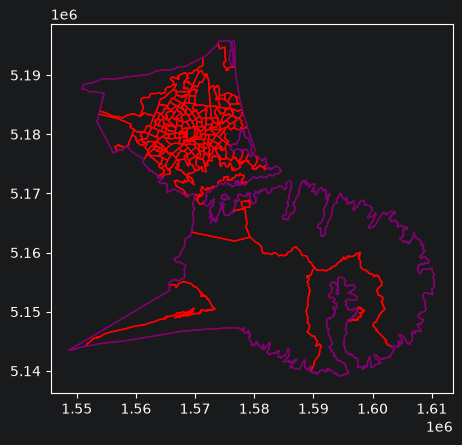

In [137]:
# Validating via visual inspection below

# Plotting SAs in red
ax = chch_sa.plot(edgecolor = "red",
                              facecolor = "none",
                              linewidth = 1)

# And plotting the Chch area in blue on the same axes
airbnb_chch_area.plot(ax = ax,
                      edgecolor = "blue",
                      facecolor = "none",
                      linewidth = 1,
                      alpha = 0.5)


## Filtering the Tenancy Services dataset to just the statistical areas identified above

As the statistical areas are now identified, we can use this list to filter (ie, use a join) to slim down the Tenancy Services dataset to include observations for the areas of interest.

In [138]:
# First, importing TS dataset
ts_data = pd.read_csv("../Data/Detailed-Quarterly-Tenancy-Q1-2020-Q3-2026.csv")

ts_data.head()

,TimeFrame,Location Id,Dwelling Type,Number Of Beds,Total Bonds,Active Bonds,Closed Bonds,Median Rent,Geometric Mean Rent,Upper Quartile Rent,Lower Quartile Rent,Log Std Dev Weekly Rent
0,2026-04-01,NaN,ALL,1,2064,19563,1176,NaN,NaN,NaN,NaN,NaN
1,2026-04-01,-99.0,ALL,1,22014,113820,6969,550.0,522.0,660.0,450.0,0.4144
2,2026-04-01,100100.0,ALL,1,6,9,0,425.0,408.0,475.0,370.0,0.2834
3,2026-04-01,100600.0,ALL,1,6,12,3,588.0,585.0,720.0,545.0,0.2550
4,2026-04-01,100700.0,ALL,1,6,30,3,550.0,530.0,579.0,473.0,0.1588


In [139]:
# Now to filter the TS dataset (location Id) by the areas identified in chch_sa

# Getting the area codes of interest for is.in
chch_codes = chch_sa["SA22019_V1"]

# Casting Location Id values to nullable int (seems to be a float?)
ts_data["Location Id"] = ts_data["Location Id"].astype("Int64")

# Same with chch_codes (might be str)
chch_codes = chch_codes.astype("Int64")

# Using is.in to filter the dataset
ts_chch = ts_data[ts_data["Location Id"].isin(chch_codes)]

ts_chch.head(5)

,TimeFrame,Location Id,Dwelling Type,Number Of Beds,Total Bonds,Active Bonds,Closed Bonds,Median Rent,Geometric Mean Rent,Upper Quartile Rent,Lower Quartile Rent,Log Std Dev Weekly Rent
1022,2026-04-01,316600,ALL,1,9,27,0,590.0,494.0,655.0,550.0,0.5975
1023,2026-04-01,316800,ALL,1,12,12,6,420.0,419.0,440.0,290.0,0.6007
1024,2026-04-01,316900,ALL,1,9,24,0,625.0,620.0,650.0,550.0,0.1417
1025,2026-04-01,317300,ALL,1,9,39,0,610.0,458.0,610.0,538.0,0.6683
1026,2026-04-01,317400,ALL,1,6,12,0,665.0,677.0,723.0,627.0,0.1733


In [141]:
# Exporting back out to Data folder as a csv
ts_chch.to_csv("../Data/tenancy_services_chch_only.csv", index = False)